# 4 — Modelo OLS com dummies (calendário + meteorologia)

Lê `data/processed/cgh_taxi_features_2025.parquet` (notebook `2`) e estima o
efeito do **calendário** e da **meteorologia** sobre o taxi-out por regressão
linear com variáveis dummy.

A variável dependente é `log(taxi_out)`: o taxi-out é uma duração positiva e
assimétrica, e o log normaliza os resíduos

## Categorias de referência (a leitura dos coeficientes é sempre relativa a elas)

| Fator | Referência |
|---|---|
| `mes` | Janeiro |
| `dia_semana` | Segunda-feira |
| `bloco` | `<06:00` (antes das 06h, baixo movimento) |
| `cia_aerea` | AZU (Azul) |
| `feriado` | 0 (dia normal) |
| `chuva` | sem chuva |
| `vis_cat` | ≥5000 m (boa visibilidade) |
| `teto_cat` | >1500 ft (teto alto) |
| `vento_cat` | <15 kt (vento fraco) |
| `cabeceira_em_uso` | 17 |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

df = pd.read_parquet("data/processed/cgh_taxi_features_2025.parquet")

DIAS_PT = ["Segunda", "Terca", "Quarta", "Quinta", "Sexta", "Sabado", "Domingo"]
df["dia_semana"] = pd.Categorical(df["dia_semana"], categories=DIAS_PT, ordered=True)

print(len(df), "decolagens")


75013 decolagens


## 4.1 Estimação do modelo

O modelo usa dummies de todos os preditores disponíveis na cabine. As
meteorológicas entram como categóricas ordinais (a referência é sempre o bom
tempo), e `trovoada`/`vento_rajada`/`troca_cabeceira` como indicadores 0/1.


In [2]:
FORMULA = (
    "log_taxi ~ C(mes) + C(dia_semana) + C(bloco) + C(cia_aerea) + C(feriado)"
    " + C(chuva) + C(vis_cat) + C(teto_cat) + C(vento_cat)"
    " + trovoada + vento_rajada + C(cabeceira_em_uso) + troca_cabeceira"
)
modelo = smf.ols(FORMULA, df).fit()

print(f"n = {int(modelo.nobs)} | k = {len(modelo.params)-1} dummies")
print(f"R² = {modelo.rsquared:.4f} | R² aj. = {modelo.rsquared_adj:.4f} | AIC = {modelo.aic:.0f}")
print(f"F = {modelo.fvalue:.1f} (p = {modelo.f_pvalue:.1e}) | logLik = {modelo.llf:.0f}")


n = 75013 | k = 106 dummies
R² = 0.1611 | R² aj. = 0.1599 | AIC = 31329
F = 135.7 (p = 0.0e+00) | logLik = -15558


### Tabela completa do modelo (statsmodels)

Saída padrão do OLS: para cada dummy, o coeficiente (em log), erro-padrão, `t`,
`p` e intervalo de confiança. Coeficiente positivo = alonga o taxi-out; a leitura
em % está nas seções seguintes (`exp(β) − 1`).


In [3]:
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               log_taxi   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     135.7
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:37:08   Log-Likelihood:                -15558.
No. Observations:               75013   AIC:                         3.133e+04
Df Residuals:                   74906   BIC:                         3.232e+04
Df Model:                         106                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

## 4.2 Efeitos de calendário (em %)

Cada barra é a variação percentual do taxi-out em relação à referência, mantidos
os demais fatores constantes. Cinza = não significante a 5%.


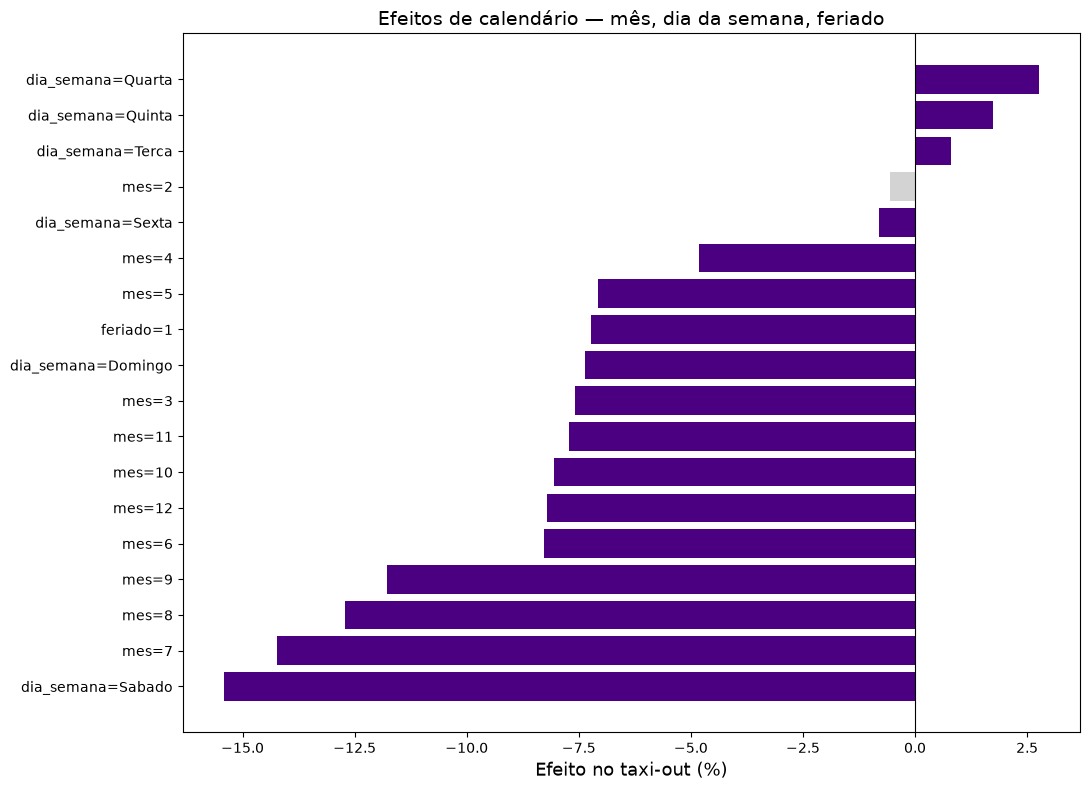

,efeito_pct,p_valor
dia_semana=Sabado,-15.42,0.00
mes=7,-14.22,0.00
mes=8,-12.71,0.00
mes=9,-11.77,0.00
mes=6,-8.27,0.00
mes=12,-8.22,0.00
mes=10,-8.05,0.00
mes=11,-7.71,0.00
mes=3,-7.59,0.00
dia_semana=Domingo,-7.36,0.00


In [4]:
def efeitos(termos_contem):
    """Coeficientes cujo nome contem algum dos padroes, em % (exp(b)-1)."""
    idx = [p for p in modelo.params.index
           if p != "Intercept" and any(t in p for t in termos_contem)]
    out = pd.DataFrame({
        "efeito_pct": (np.exp(modelo.params[idx]) - 1) * 100,
        "p_valor": modelo.pvalues[idx],
    })
    return out


def rotulo(p):
    """Encolhe 'C(mes)[T.3]' -> 'mes=3', 'C(chuva)[T.forte]' -> 'chuva=forte'."""
    if "[T." not in p:
        return p
    fator = p.split("(")[1].split(")")[0] if p.startswith("C(") else p.split("[")[0]
    nivel = p.split("[T.")[1].rstrip("]")
    return f"{fator}={nivel}"


cal = efeitos(["C(mes)", "C(dia_semana)", "C(feriado)"])
cal.index = [rotulo(p) for p in cal.index]
cal = cal.sort_values("efeito_pct")

plt.figure(figsize=(11, 8))
cores = np.where(cal["p_valor"] < 0.05, "indigo", "lightgray")
plt.barh(cal.index, cal["efeito_pct"], color=cores)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Efeito no taxi-out (%)", fontsize=13)
plt.title("Efeitos de calendário — mês, dia da semana, feriado", fontsize=14)
plt.tight_layout(); plt.show()
display(cal.round(2))


## 4.3 Efeitos meteorológicos (em %)

O sinal esperado: chuva e vento forte alongam o taxi. O teto aparece com efeito
fraco/negativo — a ser lido com cuidado (dias de teto baixo têm menos tráfego
visual em CGH-principalmente helicopteros). As faixas severas têm poucos voos; ver o `n` na EDA (notebook `3`).


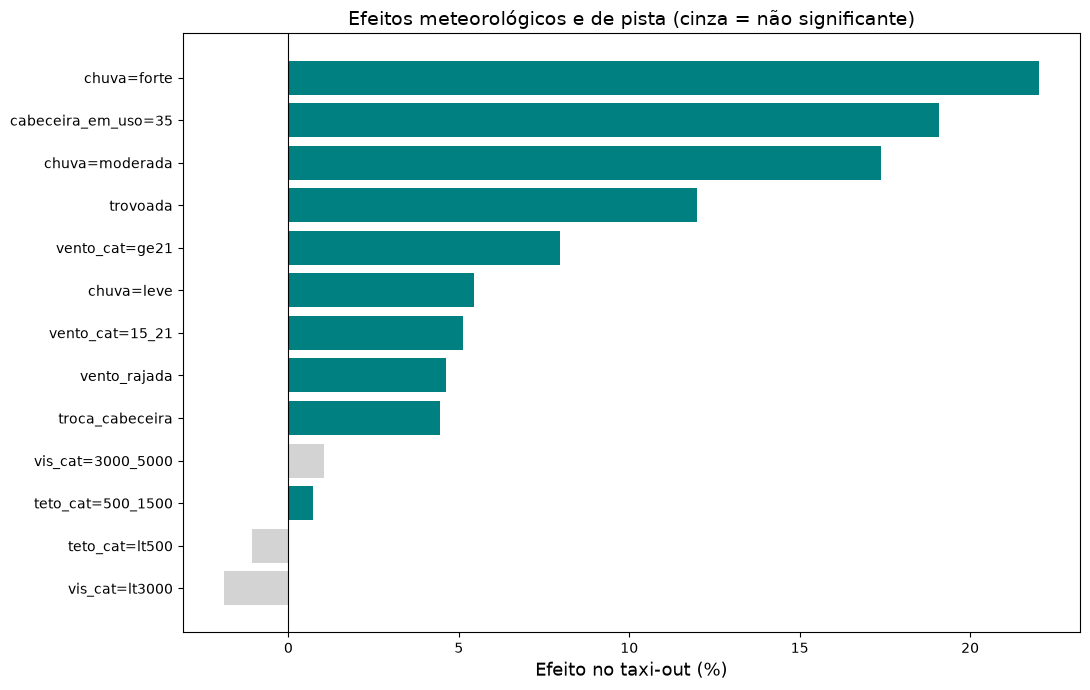

,efeito_pct,p_valor
vis_cat=lt3000,-1.90,0.53
teto_cat=lt500,-1.07,0.41
teto_cat=500_1500,0.72,0.01
vis_cat=3000_5000,1.05,0.31
troca_cabeceira,4.45,0.00
vento_rajada,4.61,0.00
vento_cat=15_21,5.12,0.00
chuva=leve,5.46,0.00
vento_cat=ge21,7.98,0.00
trovoada,11.98,0.00


In [5]:
meteo = efeitos(["C(chuva)", "C(vis_cat)", "C(teto_cat)", "C(vento_cat)",
                 "trovoada", "vento_rajada", "cabeceira", "troca_cabeceira"])
meteo.index = [rotulo(p) for p in meteo.index]
meteo = meteo.sort_values("efeito_pct")

plt.figure(figsize=(11, 7))
cores = np.where(meteo["p_valor"] < 0.05, "teal", "lightgray")
plt.barh(meteo.index, meteo["efeito_pct"], color=cores)
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Efeito no taxi-out (%)", fontsize=13)
plt.title("Efeitos meteorológicos e de pista (cinza = não significante)", fontsize=14)
plt.tight_layout(); plt.show()
display(meteo.round(2))


## 4.4 Perfil intradiário (efeito do bloco de horário)

O bloco de horário é o eixo em que se espera o maior efeito — os picos de
congestionamento alongam o taxi. A referência é `<06:00`.


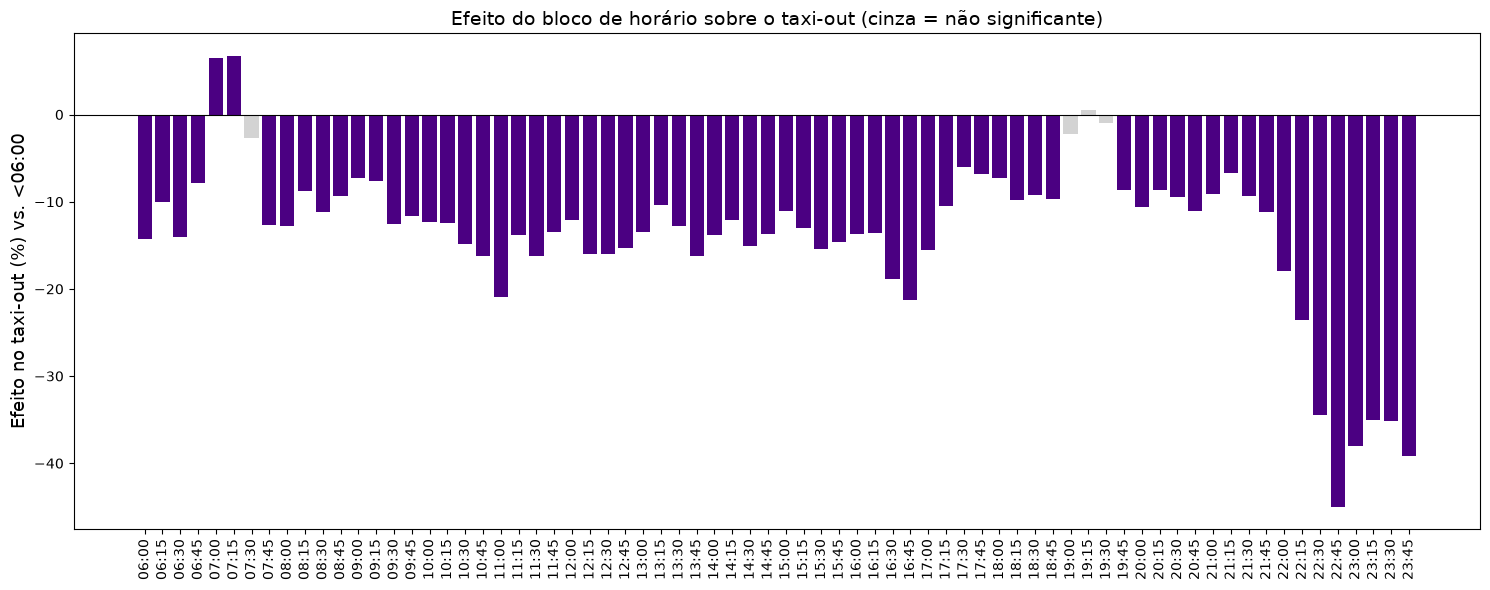

In [6]:
bl = efeitos(["C(bloco)"])
bl.index = [rotulo(p).replace("bloco=", "") for p in bl.index]
# ordena pela ordem cronologica do bloco
ordem = [b for b in df["bloco"].cat.categories.astype(str) if b in bl.index]
bl = bl.reindex(ordem)

plt.figure(figsize=(15, 6))
cores = np.where(bl["p_valor"] < 0.05, "indigo", "lightgray")
plt.bar(bl.index, bl["efeito_pct"], color=cores)
plt.axhline(0, color="black", lw=0.8)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("Efeito no taxi-out (%) vs. <06:00", fontsize=13)
plt.title("Efeito do bloco de horário sobre o taxi-out (cinza = não significante)", fontsize=14)
plt.tight_layout(); plt.show()


## 4.5 Resíduos e ajuste

O `R²` modesto é esperado e é o ponto central do trabalho: o calendário e a
meteorologia disponíveis na cabine explicam apenas um pouco da variância.


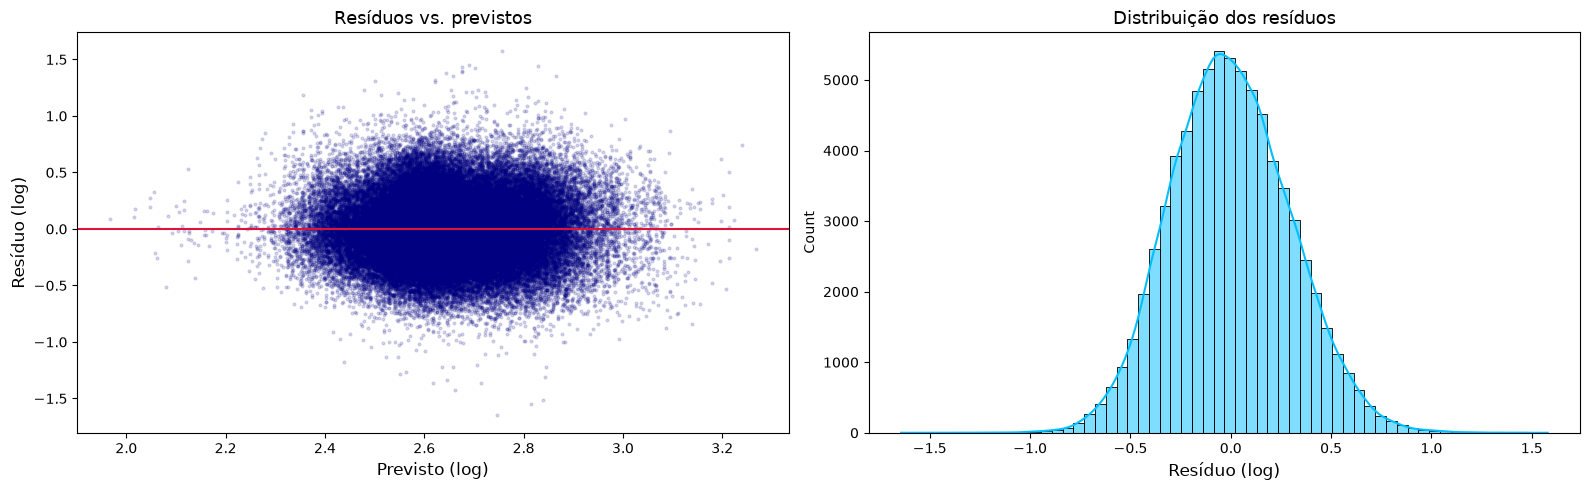

R² = 0.1611 | R² aj. = 0.1599 | AIC = 31329 | n = 75013
R² baixo é esperado (efeitos fixos de cabine); o dia entra como nível 2 no nb 5.


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
ax[0].scatter(modelo.fittedvalues, modelo.resid, s=4, alpha=0.15, color="navy")
ax[0].axhline(0, color="crimson", lw=1.5)
ax[0].set_xlabel("Previsto (log)", fontsize=12)
ax[0].set_ylabel("Resíduo (log)", fontsize=12)
ax[0].set_title("Resíduos vs. previstos", fontsize=13)

sns.histplot(modelo.resid, bins=60, kde=True, color="deepskyblue", ax=ax[1])
ax[1].set_xlabel("Resíduo (log)", fontsize=12)
ax[1].set_title("Distribuição dos resíduos", fontsize=13)
plt.tight_layout(); plt.show()

print(f"R² = {modelo.rsquared:.4f} | R² aj. = {modelo.rsquared_adj:.4f} | "
      f"AIC = {modelo.aic:.0f} | n = {int(modelo.nobs)}")
